In [1]:
import pandas as pd

In [2]:
csv = pd.read_csv('./reports/report.csv')
df = pd.DataFrame(csv)


In [3]:
df.head()

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
0,0,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,Controlled Fall
1,1,Fall,Fall,SlipTrip,Controlled Fall,SlipTrip,Controlled Fall
2,2,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,Controlled Fall
3,3,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,Controlled Fall
4,4,Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall


In [4]:
df.tail()

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
403,403,Fall,Fall,SlipTrip,SlipTrip,Hard Fall,SlipTrip
404,404,Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
405,405,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
406,406,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
407,407,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall


In [5]:
df

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
0,0,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,Controlled Fall
1,1,Fall,Fall,SlipTrip,Controlled Fall,SlipTrip,Controlled Fall
2,2,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,Controlled Fall
3,3,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,Controlled Fall
4,4,Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
...,...,...,...,...,...,...,...
403,403,Fall,Fall,SlipTrip,SlipTrip,Hard Fall,SlipTrip
404,404,Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
405,405,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall
406,406,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall,Not Fall


In [6]:
df[(df["Autoencoder"] == "Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0                      202
Autoencoder                     202
State Detector (Resnet18)       202
Health Assessment (ResNet34)    202
Hybrid                          202
Classic                         202
True                            202
dtype: int64

In [7]:
df[(df["Autoencoder"] == "Fall") & (df["True"] == "Not Fall")].count()


Unnamed: 0                      93
Autoencoder                     93
State Detector (Resnet18)       93
Health Assessment (ResNet34)    93
Hybrid                          93
Classic                         93
True                            93
dtype: int64

In [8]:
df[(df["Autoencoder"] == "Not Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0                      2
Autoencoder                     2
State Detector (Resnet18)       2
Health Assessment (ResNet34)    2
Hybrid                          2
Classic                         2
True                            2
dtype: int64

In [9]:
df[(df["State Detector (Resnet18)"] == "Fall") & (df["True"] == "Not Fall")].count()

Unnamed: 0                      5
Autoencoder                     5
State Detector (Resnet18)       5
Health Assessment (ResNet34)    5
Hybrid                          5
Classic                         5
True                            5
dtype: int64

In [10]:
df[(df["State Detector (Resnet18)"] == "Not Fall") & (df["True"] != "Not Fall")].count()

Unnamed: 0                      0
Autoencoder                     0
State Detector (Resnet18)       0
Health Assessment (ResNet34)    0
Hybrid                          0
Classic                         0
True                            0
dtype: int64

In [11]:
import matplotlib.pyplot as plt

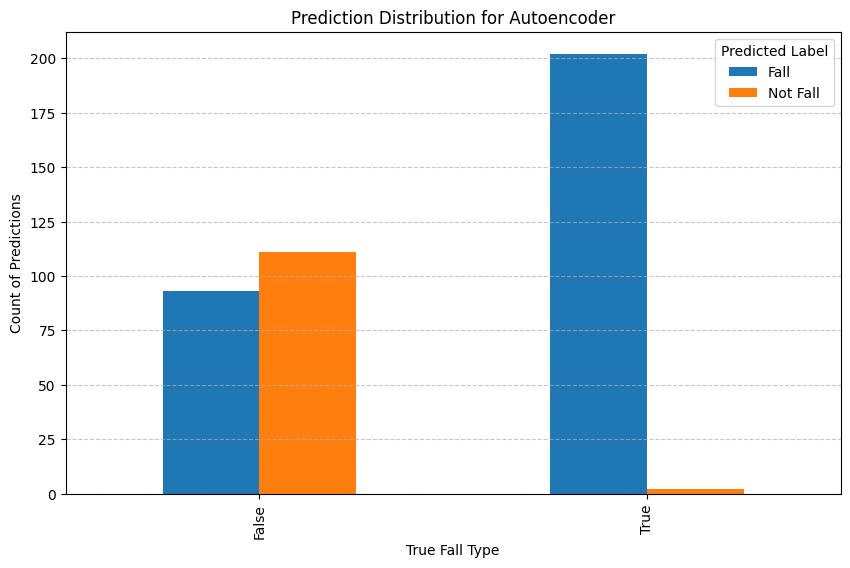

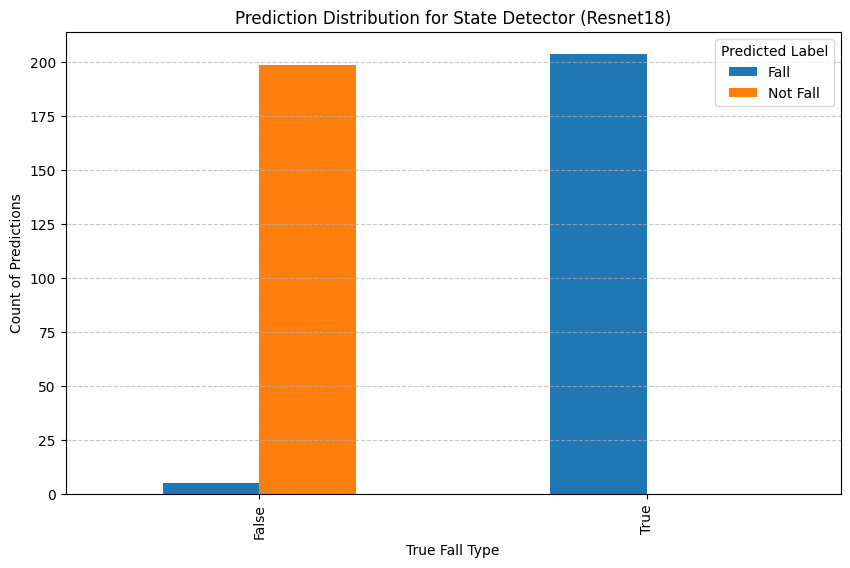

In [12]:
models = ["Autoencoder", "State Detector (Resnet18)"]

for model in models:
    counts = []
    labels = []

    # Build a table of how model predictions distribute for each true label
    pivot = pd.crosstab(df["True"] != "Not Fall", df[model])

    # Plot
    pivot.plot(kind="bar", figsize=(10,6))
    plt.title(f"Prediction Distribution for {model}")
    plt.xlabel("True Fall Type")
    plt.ylabel("Count of Predictions")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Predicted Label")
    plt.show()

# Prepare to only keep the rows the the state and autoencoder was correct
- This will ensure that the other predicitons is predicting a fall, when there accutally was a fall

In [13]:
df = df[df["True"] != "Not Fall"]

### Find out if all cases where both the ae and the sd belived it was not fall even if it was

In [14]:
df[(df["Autoencoder"] == "Not Fall") & (df["State Detector (Resnet18)"] == "Not Fall")]

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True


In [15]:
amount_of_fall = len(df)

In [16]:
df[(df["Health Assessment (ResNet34)"] == "Hard Fall") & (df["True"] == "Hard Fall")]

,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
88,88,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
89,89,Fall,Fall,Hard Fall,Hard Fall,SlipTrip,Hard Fall
90,90,Fall,Fall,Hard Fall,Hard Fall,SlipTrip,Hard Fall
91,91,Fall,Fall,Hard Fall,Hard Fall,Controlled Fall,Hard Fall
96,96,Fall,Fall,Hard Fall,Hard Fall,SlipTrip,Hard Fall
...,...,...,...,...,...,...,...
235,235,Fall,Fall,Hard Fall,Hard Fall,Controlled Fall,Hard Fall
240,240,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
241,241,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall
242,242,Fall,Fall,Hard Fall,Hard Fall,Hard Fall,Hard Fall


In [17]:
df[(df["Health Assessment (ResNet34)"] == "SlipTrip") & (df["True"] == "SlipTrip")]


,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
248,248,Fall,Fall,SlipTrip,Hard Fall,Hard Fall,SlipTrip
249,249,Fall,Fall,SlipTrip,Hard Fall,SlipTrip,SlipTrip
250,250,Fall,Fall,SlipTrip,Hard Fall,SlipTrip,SlipTrip
251,251,Fall,Fall,SlipTrip,Hard Fall,Controlled Fall,SlipTrip
256,256,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
...,...,...,...,...,...,...,...
395,395,Fall,Fall,SlipTrip,Hard Fall,Hard Fall,SlipTrip
400,400,Fall,Fall,SlipTrip,Hard Fall,Hard Fall,SlipTrip
401,401,Fall,Fall,SlipTrip,SlipTrip,SlipTrip,SlipTrip
402,402,Fall,Fall,SlipTrip,Hard Fall,SlipTrip,SlipTrip


In [18]:
df[(df["Health Assessment (ResNet34)"] == "Controlled Fall") & (df["True"] == "Controlled Fall")]


,Unnamed: 0,Autoencoder,State Detector (Resnet18),Health Assessment (ResNet34),Hybrid,Classic,True
9,9,Fall,Fall,Controlled Fall,Controlled Fall,SlipTrip,Controlled Fall
17,17,Fall,Fall,Controlled Fall,Controlled Fall,Controlled Fall,Controlled Fall
18,18,Fall,Fall,Controlled Fall,Hard Fall,Hard Fall,Controlled Fall
33,33,Fall,Fall,Controlled Fall,Controlled Fall,SlipTrip,Controlled Fall
34,34,Fall,Fall,Controlled Fall,Controlled Fall,SlipTrip,Controlled Fall
50,50,Fall,Fall,Controlled Fall,Hard Fall,SlipTrip,Controlled Fall
66,66,Fall,Fall,Controlled Fall,Controlled Fall,SlipTrip,Controlled Fall


In [19]:
df[(df["Health Assessment (ResNet34)"] == "Hard Fall") & (df["True"] != "Hard Fall")].count()

Unnamed: 0                      40
Autoencoder                     40
State Detector (Resnet18)       40
Health Assessment (ResNet34)    40
Hybrid                          40
Classic                         40
True                            40
dtype: int64

In [20]:
df[(df["Health Assessment (ResNet34)"] == "SlipTrip") & (df["True"] != "SlipTrip")].count()


Unnamed: 0                      23
Autoencoder                     23
State Detector (Resnet18)       23
Health Assessment (ResNet34)    23
Hybrid                          23
Classic                         23
True                            23
dtype: int64

In [21]:
len(df)

204

In [22]:
len(df[(df["Health Assessment (ResNet34)"] != df["True"])])

65

In [23]:
(65 / 204) * 100

31.862745098039213

In [24]:
df[(df["Hybrid"] != df["True"])].count()


Unnamed: 0                      67
Autoencoder                     67
State Detector (Resnet18)       67
Health Assessment (ResNet34)    67
Hybrid                          67
Classic                         67
True                            67
dtype: int64

In [25]:
df[(df["Classic"] != df["True"])].count()


Unnamed: 0                      94
Autoencoder                     94
State Detector (Resnet18)       94
Health Assessment (ResNet34)    94
Hybrid                          94
Classic                         94
True                            94
dtype: int64

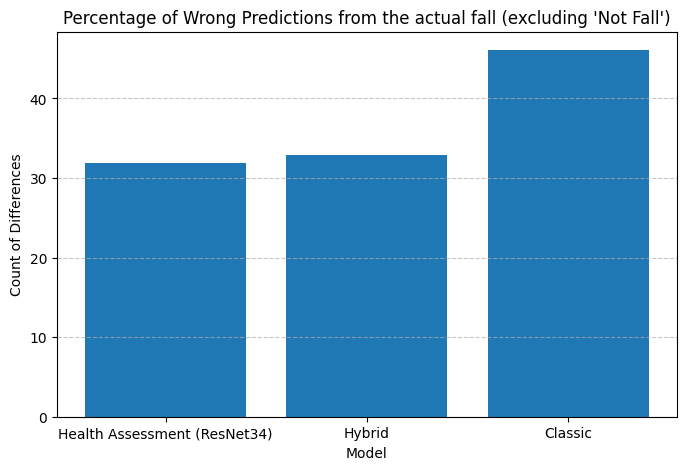

In [26]:
comparison_columns = ["Health Assessment (ResNet34)", "Hybrid", "Classic"]
differences = {col: ((len(df[(df[col] != df["True"])]) / 204) * 100) for col in comparison_columns}

# Convert to DataFrame for plotting
diff_df = pd.DataFrame(list(differences.items()), columns=["Model", "Differences"])

# Plot the results
plt.figure(figsize=(8, 5))
plt.bar(diff_df["Model"], diff_df["Differences"])
plt.title("Percentage of Wrong Predictions from the actual fall (excluding 'Not Fall')")
plt.xlabel("Model")
plt.ylabel("Count of Differences")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

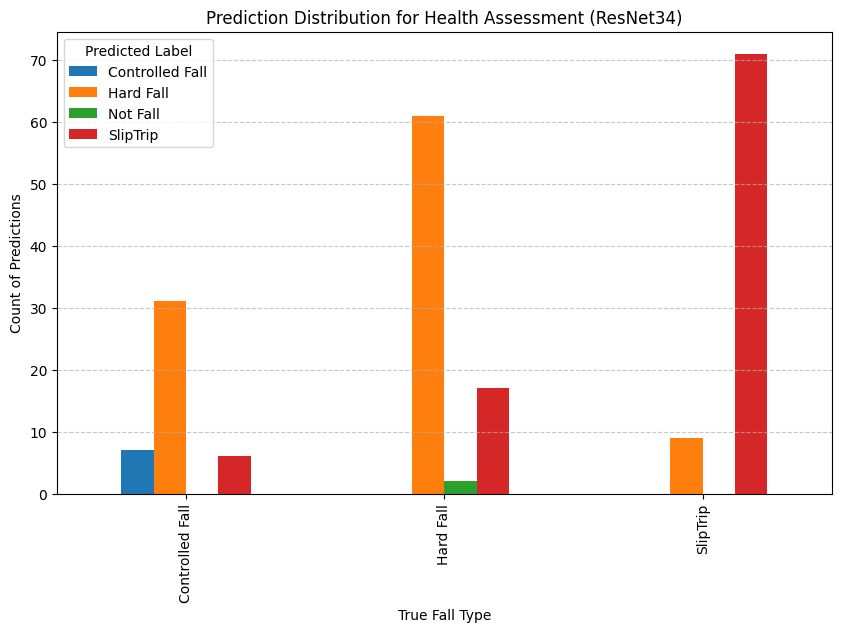

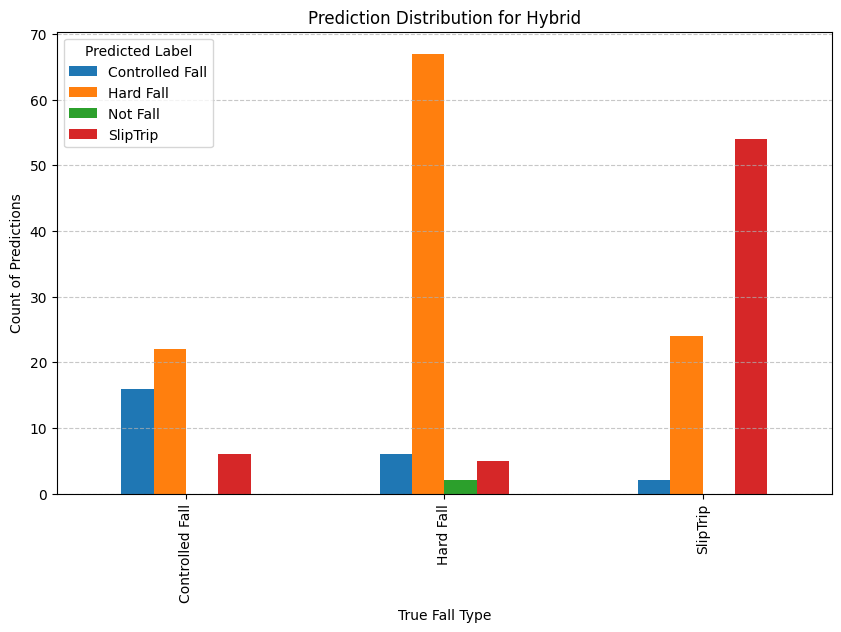

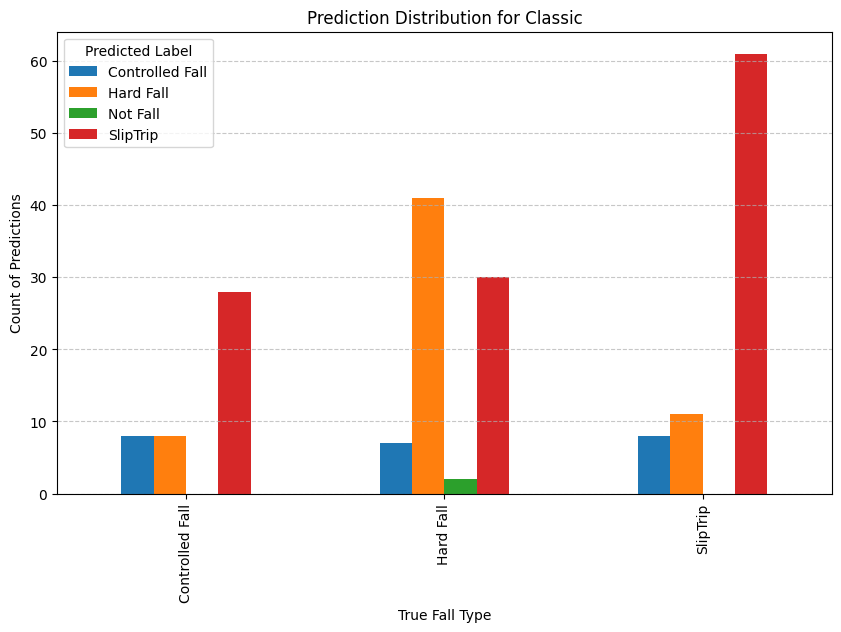

In [27]:
models = ["Health Assessment (ResNet34)", "Hybrid", "Classic"]
true_classes = df["True"].unique()

# For each model, count predictions for each true class
for model in models:
    counts = []
    labels = []

    # Build a table of how model predictions distribute for each true label
    pivot = pd.crosstab(df["True"], df[model])

    # Plot
    pivot.plot(kind="bar", figsize=(10,6))
    plt.title(f"Prediction Distribution for {model}")
    plt.xlabel("True Fall Type")
    plt.ylabel("Count of Predictions")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Predicted Label")
    plt.show()